## Notebook 1: Analyse d'exploitation

In [40]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Configuration
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print("✅ Imports effectués")

✅ Imports effectués


In [41]:
# Gestion automatique du chemin vers les fichiers de données
import os
from pathlib import Path

def locate_data_folder():
    """
    Détermine l'emplacement du dossier contenant les jeux de données.
    Plusieurs emplacements possibles sont testés avant de lever une erreur.
    """
    
    current_dir = Path.cwd().resolve()

    # Emplacements les plus probables
    possible_paths = [
        current_dir / "data",
        current_dir.parent / "data",
        current_dir.parent.parent / "data"
    ]

    for path in possible_paths:
        if path.is_dir():
            return path.resolve()

    # Vérification d'un dossier de projet alternatif
    project_dir = current_dir.parent / "Projet+Mise+en+prod+-+home-credit-default-risk"
    if project_dir.exists():
        return project_dir.resolve()

    # Recherche d'un fichier de référence dans l'arborescence
    target_file = "application_train.csv"
    for directory in [current_dir, *current_dir.parents]:
        result = list(directory.rglob(target_file))
        if result:
            return result[0].parent.resolve()

    # Dernière tentative : lecture depuis une variable d'environnement
    custom_path = os.getenv("DATA_DIR")
    if custom_path:
        custom_path = Path(custom_path).expanduser().resolve()
        if custom_path.exists():
            return custom_path

    raise FileNotFoundError(
        "Impossible de trouver le dossier des données."
    )

# Détection du répertoire contenant les CSV
try:
    DATA_DIR = locate_data_folder()
    print(f"✅ Répertoire détecté : {DATA_DIR}")

except FileNotFoundError as error:
    print(error)
    DATA_DIR = Path("../data").resolve()
    print(f"⚠️ Répertoire par défaut utilisé : {DATA_DIR}")

# Affichage du contenu disponible
print("\n📊 Fichiers CSV trouvés :")
for csv_file in DATA_DIR.glob("*.csv"):
    file_size = csv_file.stat().st_size / (1024 * 1024)
    print(f"• {csv_file.name} - {file_size:.2f} Mo")

✅ Répertoire détecté : C:\Users\domir

📊 Fichiers CSV trouvés :
• application_test.csv - 25.34 Mo
• application_train.csv - 158.44 Mo
• bureau.csv - 162.14 Mo
• bureau_balance.csv - 358.19 Mo
• HomeCredit_columns_description.csv - 0.04 Mo
• installments_payments.csv - 689.62 Mo
• POS_CASH_balance.csv - 374.51 Mo
• previous_application.csv - 386.21 Mo
• sample_submission.csv - 0.51 Mo


## 1. Importation des données principales

In [42]:
# Import des jeux de données principaux
train_df = pd.read_csv(DATA_DIR / "application_train.csv")
test_df = pd.read_csv(DATA_DIR / "application_test.csv")

print(
    f"Jeu d'entraînement : {train_df.shape[0]:,} observations et {train_df.shape[1]} variables"
)
print(
    f"Jeu de test : {test_df.shape[0]:,} observations et {test_df.shape[1]} variables"
)

Jeu d'entraînement : 307,511 observations et 122 variables
Jeu de test : 48,744 observations et 121 variables


In [43]:
# Afficher les 5 premières observations du jeu d'entraînement
display(train_df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

In [44]:
# Répartition des colonnes par type
print("\n🔎 Distribution des types de variables :")
print(train_df.dtypes.value_counts())


🔎 Distribution des types de variables :
float64    65
int64      41
str        16
Name: count, dtype: int64


## 2. Étude de la variable cible (TARGET)

In [45]:
# Analyse de la distribution de TARGET
effectifs = train_df["TARGET"].value_counts()
pourcentages = train_df["TARGET"].value_counts(normalize=True).mul(100)

print("Résumé de la variable cible")
print("-" * 35)

for classe in effectifs.index:
    print(
        f"TARGET = {classe} : {effectifs[classe]:,} observations "
        f"({pourcentages[classe]:.2f}%)"
    )

print(
    f"\nDéséquilibre des classes : "
    f"{effectifs[0] / effectifs[1]:.1f} observations de la classe 0 "
    + f"pour 1 observation de la classe 1"
)


Résumé de la variable cible
-----------------------------------
TARGET = 0 : 282,686 observations (91.93%)
TARGET = 1 : 24,825 observations (8.07%)

Déséquilibre des classes : 11.4 observations de la classe 0 pour 1 observation de la classe 1


In [46]:
# Analyse de la répartition des classes
target_counts = train_df['TARGET'].value_counts()
target_pct = train_df['TARGET'].value_counts(normalize=True) * 100

print("📈 Répartition de la variable cible :")
print(f"   Classe 0 (clients sans défaut) : {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"   Classe 1 (clients en défaut) : {target_counts[1]:,} ({target_pct[1]:.2f}%)")

print(
    f"\n🔍 Rapport entre les classes : "
    f"{target_counts[0] / target_counts[1]:.1f} observations de la classe 0 pour 1 de la classe 1"
)

📈 Répartition de la variable cible :
   Classe 0 (clients sans défaut) : 282,686 (91.93%)
   Classe 1 (clients en défaut) : 24,825 (8.07%)

🔍 Rapport entre les classes : 11.4 observations de la classe 0 pour 1 de la classe 1


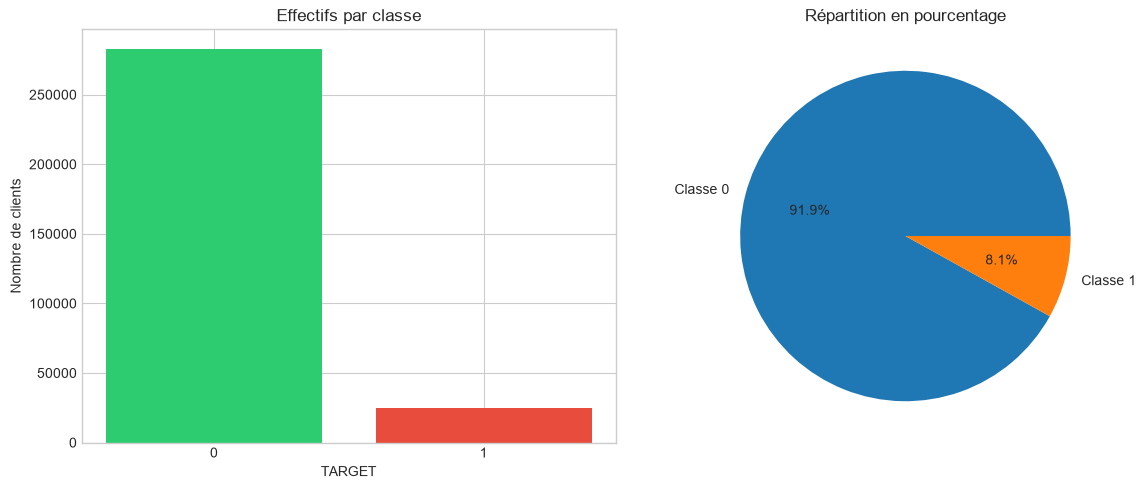

In [47]:
# Aperçu graphique de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogramme des effectifs
axes[0].bar(target_counts.index.astype(str),
            target_counts.values,
            color=["#2ecc71", "#e74c3c"])

axes[0].set_title("Effectifs par classe")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Nombre de clients")

# Camembert des proportions
axes[1].pie(
    target_pct.values,
    labels=[f"Classe {c}" for c in target_pct.index],
    autopct="%.1f%%"
)

axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.show()

## 3. Analyse des Valeurs Manquantes

In [48]:
# Évaluation du taux de données manquantes par variable
missing = train_df.isnull().sum() / len(train_df) * 100
missing = missing[missing > 0].sort_values(ascending=False)

print(f"📈 {len(missing)} variables contiennent au moins une valeur manquante sur {train_df.shape[1]} variables")
print("\n📋 Les 20 variables les plus affectées par les valeurs manquantes :")
print(missing.head(20))

📈 67 variables contiennent au moins une valeur manquante sur 122 variables

📋 Les 20 variables les plus affectées par les valeurs manquantes :
COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64


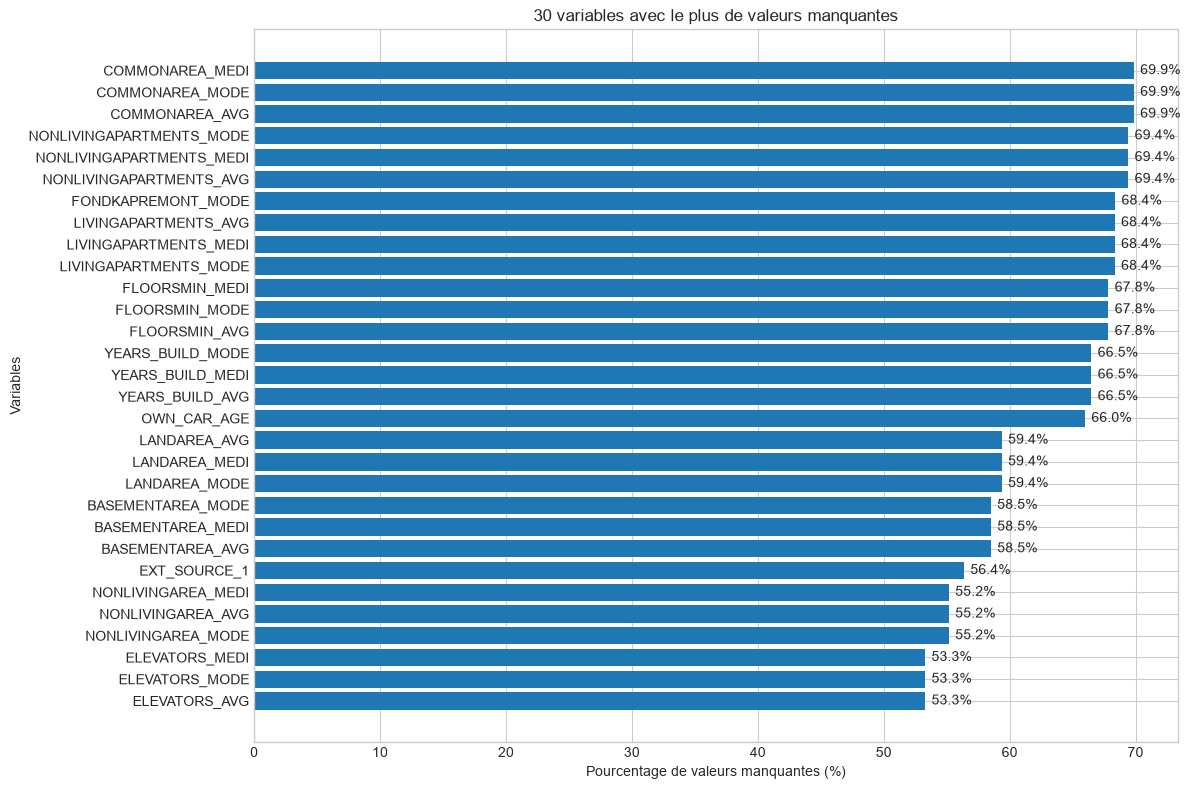

In [49]:
# Visualisation des variables contenant le plus de valeurs manquantes
fig, ax = plt.subplots(figsize=(12, 8))

top_missing = missing.head(30)

ax.barh(
    top_missing.index,
    top_missing.values
)

ax.set_title("30 variables avec le plus de valeurs manquantes")
ax.set_xlabel("Pourcentage de valeurs manquantes (%)")
ax.set_ylabel("Variables")

# Affichage des pourcentages sur les barres
for i, value in enumerate(top_missing.values):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

ax.invert_yaxis()

plt.tight_layout()

# Sauvegarde dans le dossier courant
plt.savefig("top_missing_features.png", dpi=150)

plt.show()

## 4. Exploration des variables numériques

In [50]:
# Sélection des principales variables quantitatives
numeric_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

# Résumé statistique des variables sélectionnées
train_df[numeric_features].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000
mean,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,-16036.995067,63815.045904,-4986.120328,-2994.202373,0.502130,5.143927e-01,0.510853
std,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,4363.988632,141275.766519,3522.886321,1509.450419,0.211062,1.910602e-01,0.194844
min,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.014568,8.173617e-08,0.000527
25%,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,-19682.000000,-2760.000000,-7479.500000,-4299.000000,0.334007,3.924574e-01,0.370650
50%,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,-15750.000000,-1213.000000,-4504.000000,-3254.000000,0.505998,5.659614e-01,0.535276
75%,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,-12413.000000,-289.000000,-2010.000000,-1720.000000,0.675053,6.636171e-01,0.669057
max,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,-7489.000000,365243.000000,0.000000,0.000000,0.962693,8.549997e-01,0.896010


In [51]:
# Préparation de variables supplémentaires pour l'analyse
analysis_df = train_df.copy()

# Conversion des durées exprimées en jours vers des années
analysis_df["AGE"] = abs(analysis_df["DAYS_BIRTH"]) / 365
analysis_df["YEARS_WORKED"] = abs(analysis_df["DAYS_EMPLOYED"]) / 365

# Remplacement de la valeur aberrante par une valeur manquante
analysis_df["YEARS_WORKED"] = analysis_df["YEARS_WORKED"].replace(1000.67, np.nan)

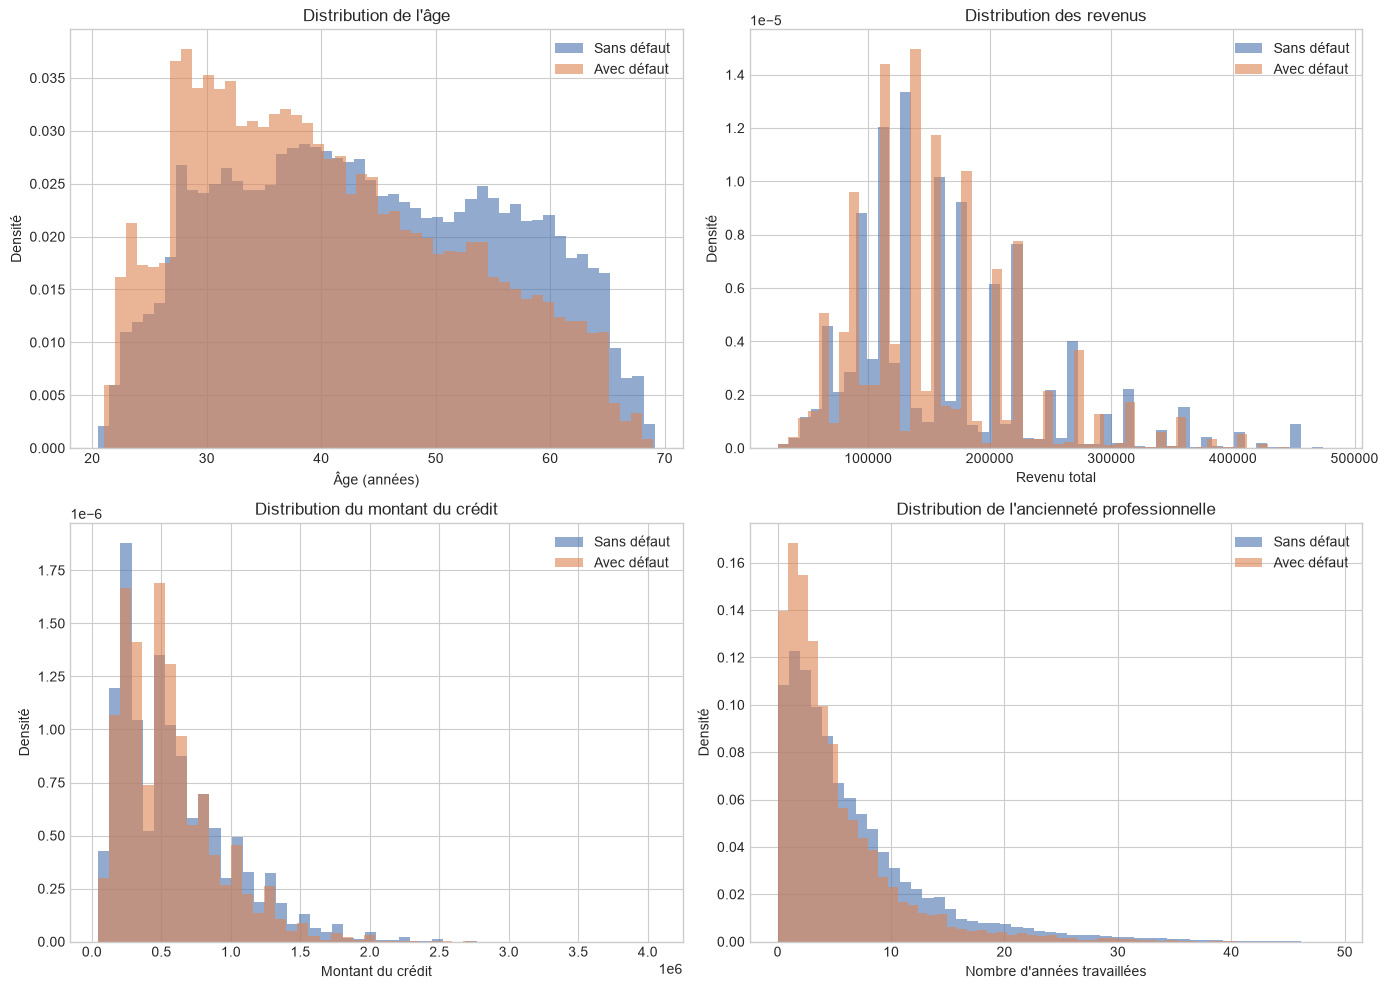

In [52]:
# Visualisation des principales variables numériques selon la classe TARGET
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Palette de couleurs
colors = {
    0: "#4c72b0",  # Bleu
    1: "#dd8452"   # Orange
}

labels = {
    0: "Sans défaut",
    1: "Avec défaut"
}

# 1. Distribution de l'âge
for target in [0, 1]:
    age_values = analysis_df.loc[
        analysis_df["TARGET"] == target,
        "AGE"
    ]

    axes[0, 0].hist(
        age_values,
        bins=50,
        density=True,
        alpha=0.6,
        color=colors[target],
        label=labels[target]
    )

axes[0, 0].set_title("Distribution de l'âge")
axes[0, 0].set_xlabel("Âge (années)")
axes[0, 0].set_ylabel("Densité")
axes[0, 0].legend()

# 2. Distribution des revenus
for target in [0, 1]:
    income_values = analysis_df.loc[
        analysis_df["TARGET"] == target,
        "AMT_INCOME_TOTAL"
    ]

    # Suppression des valeurs extrêmes
    income_values = income_values[
        income_values < income_values.quantile(0.99)
    ]

    axes[0, 1].hist(
        income_values,
        bins=50,
        density=True,
        alpha=0.6,
        color=colors[target],
        label=labels[target]
    )

axes[0, 1].set_title("Distribution des revenus")
axes[0, 1].set_xlabel("Revenu total")
axes[0, 1].set_ylabel("Densité")
axes[0, 1].legend()

# 3. Distribution du montant du crédit
for target in [0, 1]:
    credit_values = analysis_df.loc[
        analysis_df["TARGET"] == target,
        "AMT_CREDIT"
    ]

    axes[1, 0].hist(
        credit_values,
        bins=50,
        density=True,
        alpha=0.6,
        color=colors[target],
        label=labels[target]
    )

axes[1, 0].set_title("Distribution du montant du crédit")
axes[1, 0].set_xlabel("Montant du crédit")
axes[1, 0].set_ylabel("Densité")
axes[1, 0].legend()

# 4. Ancienneté professionnelle
for target in [0, 1]:
    employment_values = analysis_df.loc[
        analysis_df["TARGET"] == target,
        "YEARS_WORKED"
    ].dropna()

    employment_values = employment_values[
        (employment_values > 0)
        & (employment_values < employment_values.quantile(0.99))
    ]

    axes[1, 1].hist(
        employment_values,
        bins=50,
        density=True,
        alpha=0.6,
        color=colors[target],
        label=labels[target]
    )

axes[1, 1].set_title("Distribution de l'ancienneté professionnelle")
axes[1, 1].set_xlabel("Nombre d'années travaillées")
axes[1, 1].set_ylabel("Densité")
axes[1, 1].legend()

plt.tight_layout()

# Sauvegarde de la figure
plt.savefig("numeric_distributions.png", dpi=150, bbox_inches="tight")

plt.show()

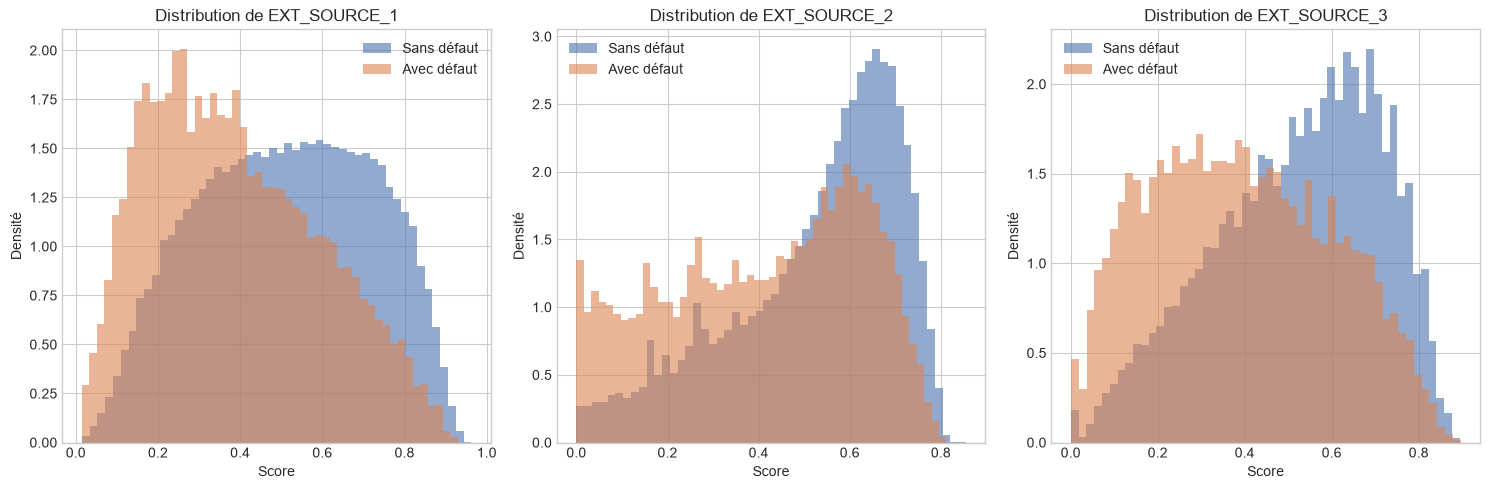

In [53]:
# Analyse des scores externes selon la variable cible
external_scores = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {
    0: "#4c72b0",  # Bleu
    1: "#dd8452"   # Orange
}

labels = {
    0: "Sans défaut",
    1: "Avec défaut"
}

for idx, feature in enumerate(external_scores):

    for target in [0, 1]:
        score_values = analysis_df.loc[
            analysis_df["TARGET"] == target,
            feature
        ].dropna()

        axes[idx].hist(
            score_values,
            bins=50,
            density=True,
            alpha=0.6,
            color=colors[target],
            label=labels[target]
        )

    axes[idx].set_title(f"Distribution de {feature}")
    axes[idx].set_xlabel("Score")
    axes[idx].set_ylabel("Densité")
    axes[idx].legend()

plt.tight_layout()

# Enregistrement de la figure
plt.savefig("external_scores_distribution.png",
            dpi=150,
            bbox_inches="tight")

plt.show()

In [54]:
# Mesure de la relation entre les scores externes et la variable cible
print("📈 Corrélations des scores externes avec TARGET :")

for feature in external_scores:
    correlation = train_df[[feature, "TARGET"]].corr().iloc[0, 1]

    print(f"   {feature} -> {correlation:.4f}")

📈 Corrélations des scores externes avec TARGET :
   EXT_SOURCE_1 -> -0.1553
   EXT_SOURCE_2 -> -0.1605
   EXT_SOURCE_3 -> -0.1789


## 6. Analyse des Variables Catégorielles

In [55]:
# Identification des variables qualitatives
categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"📈 Nombre de variables catégorielles : {len(categorical_features)}")

for feature in categorical_features:
    unique_values = train_df[feature].nunique()

    print(f"   • {feature} : {unique_values} modalités")

📈 Nombre de variables catégorielles : 16
   • NAME_CONTRACT_TYPE : 2 modalités
   • CODE_GENDER : 3 modalités
   • FLAG_OWN_CAR : 2 modalités
   • FLAG_OWN_REALTY : 2 modalités
   • NAME_TYPE_SUITE : 7 modalités
   • NAME_INCOME_TYPE : 8 modalités
   • NAME_EDUCATION_TYPE : 5 modalités
   • NAME_FAMILY_STATUS : 6 modalités
   • NAME_HOUSING_TYPE : 6 modalités
   • OCCUPATION_TYPE : 18 modalités
   • WEEKDAY_APPR_PROCESS_START : 7 modalités
   • ORGANIZATION_TYPE : 58 modalités
   • FONDKAPREMONT_MODE : 4 modalités
   • HOUSETYPE_MODE : 3 modalités
   • WALLSMATERIAL_MODE : 7 modalités
   • EMERGENCYSTATE_MODE : 2 modalités


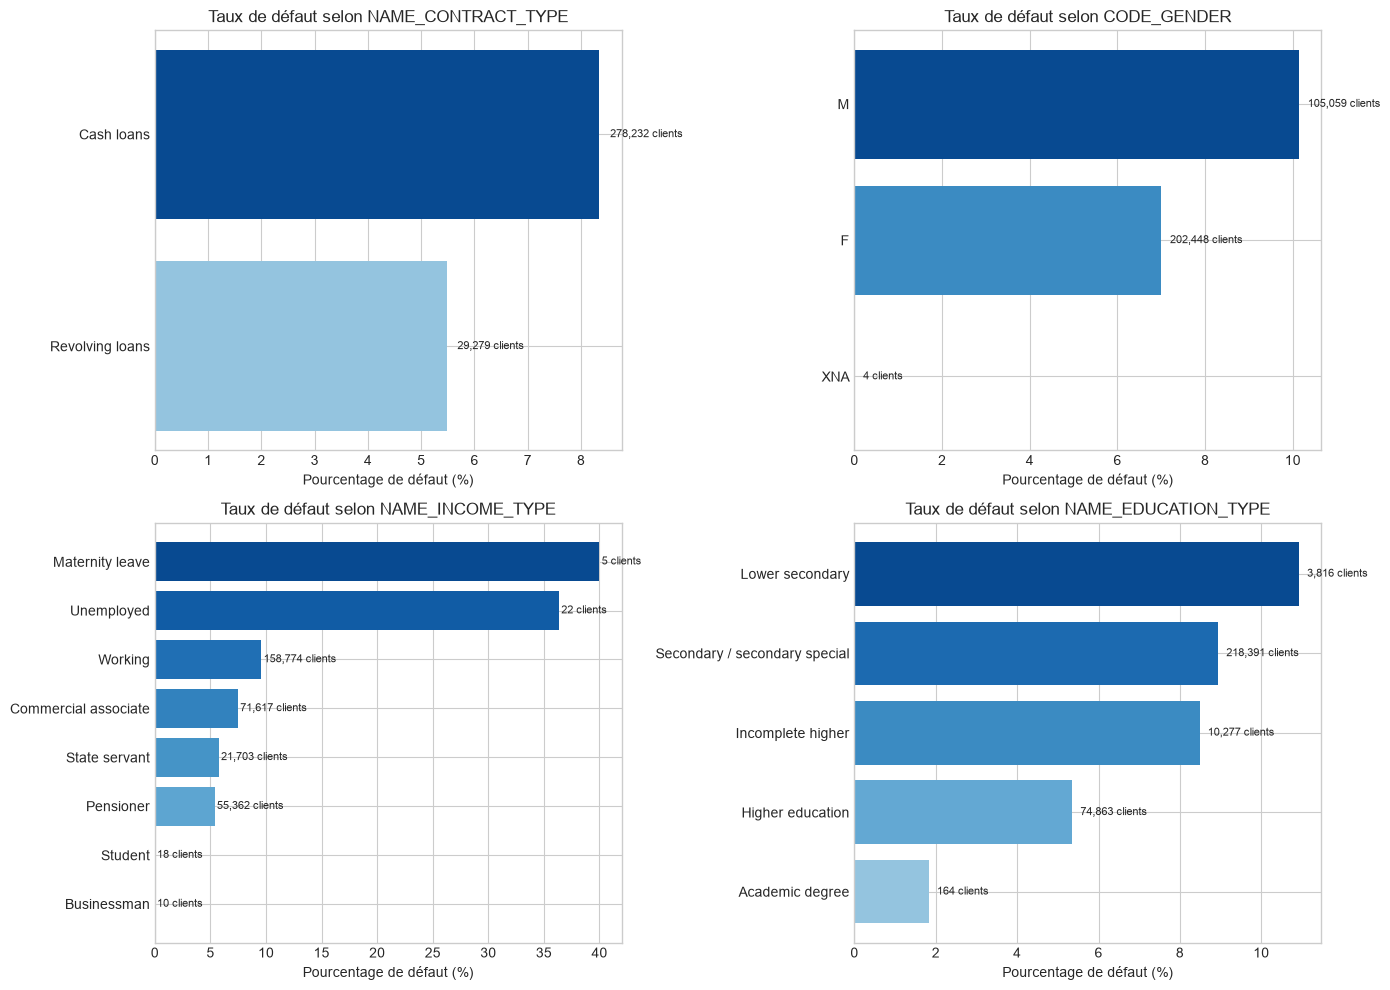

In [56]:
# Analyse du taux de défaut selon certaines variables catégorielles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

selected_categories = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE"
]

for idx, feature in enumerate(selected_categories):

    ax = axes[idx // 2, idx % 2]

    # Calcul des statistiques par catégorie
    category_stats = (
        train_df
        .groupby(feature)["TARGET"]
        .agg(
            default_rate="mean",
            clients_count="count"
        )
        .sort_values("default_rate")
    )

    # Palette de couleurs graduée
    bar_colors = plt.cm.Blues(
        np.linspace(0.4, 0.9, len(category_stats))
    )

    bars = ax.barh(
        category_stats.index,
        category_stats["default_rate"] * 100,
        color=bar_colors
    )

    ax.set_title(f"Taux de défaut selon {feature}")
    ax.set_xlabel("Pourcentage de défaut (%)")

    # Affichage du nombre d'observations
    for bar, count in zip(bars, category_stats["clients_count"]):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,} clients",
            va="center",
            fontsize=8
        )

plt.tight_layout()

# Sauvegarde du graphique
plt.savefig(
    "categorical_default_rates.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 7. Analyse des corrélations entre variables

In [57]:
# Analyse des corrélations entre les variables numériques et la cible
numeric_features = train_df.select_dtypes(include=[np.number])

target_correlations = (
    numeric_features
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values()
)

print("📈 Variables les plus positivement corrélées à TARGET :")
print(target_correlations.tail(15))

print("\n📉 Variables les plus négativement corrélées à TARGET :")
print(target_correlations.head(15))

📈 Variables les plus positivement corrélées à TARGET :
FLAG_WORK_PHONE                0.028524
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

📉 Variables les plus négativement corrélées à TARGET :
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE            

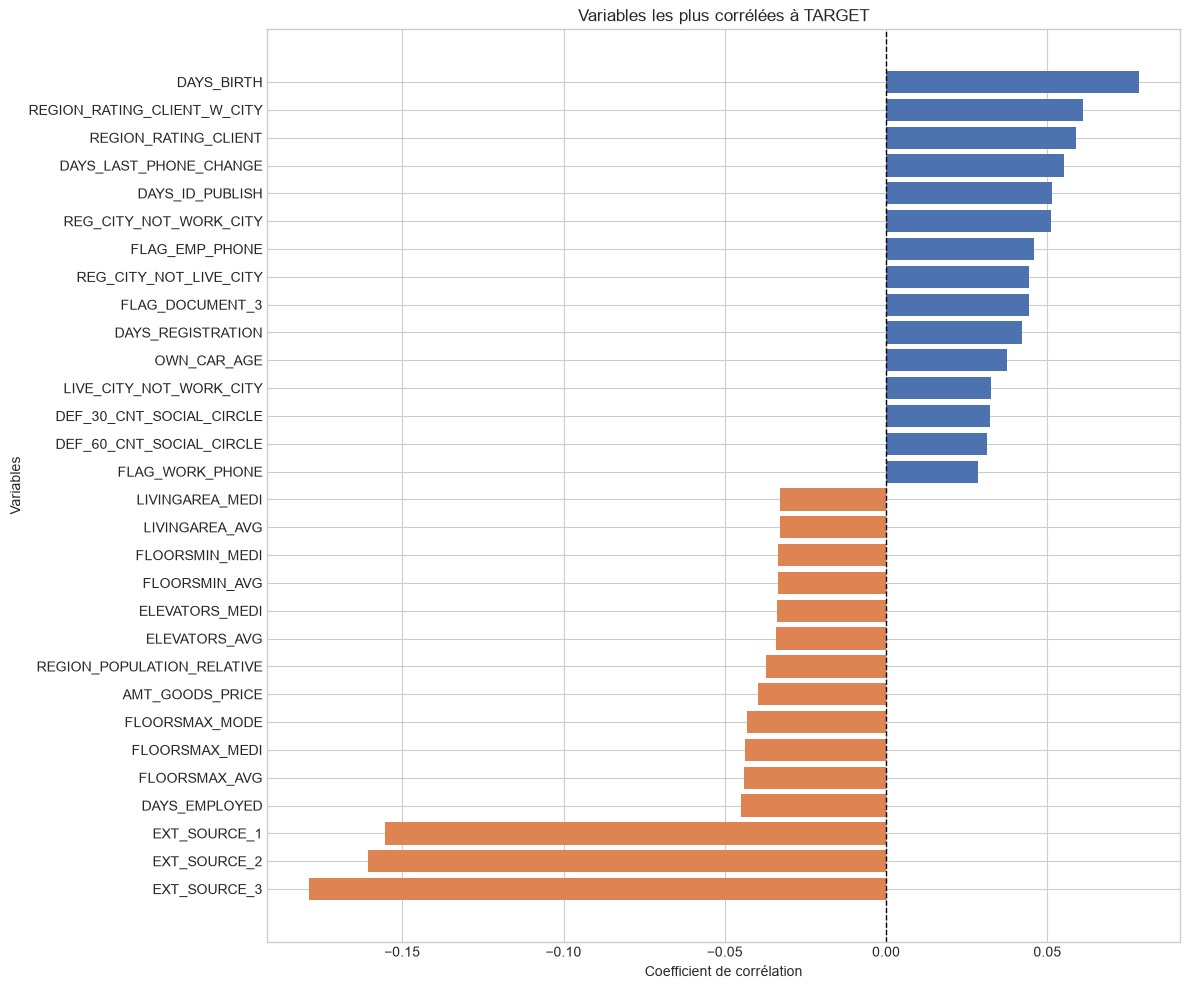

In [58]:
# Visualisation des corrélations avec TARGET
fig, ax = plt.subplots(figsize=(12, 10))

# Sélection des 15 corrélations les plus négatives et positives
top_corr = pd.concat([
    target_correlations.head(15),
    target_correlations.tail(15)
])

# Couleurs selon le signe de la corrélation
colors = [
    "#dd8452" if value < 0 else "#4c72b0"
    for value in top_corr.values
]

# Création du graphique
ax.barh(
    top_corr.index,
    top_corr.values,
    color=colors
)

# Ligne verticale de référence
ax.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title("Variables les plus corrélées à TARGET")
ax.set_xlabel("Coefficient de corrélation")
ax.set_ylabel("Variables")

plt.tight_layout()

# Sauvegarde dans le dossier courant
plt.savefig(
    "correlations_target.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 8. Regardons les Tables Supplémentaires

In [59]:
# Inventaire des tables complémentaires du projet
data_files = {
    "bureau": DATA_DIR / "bureau.csv",
    "bureau_balance": DATA_DIR / "bureau_balance.csv",
    "previous_application": DATA_DIR / "previous_application.csv",
    "installments_payments": DATA_DIR / "installments_payments.csv",
    "POS_CASH_balance": DATA_DIR / "POS_CASH_balance.csv",
    "credit_card_balance": DATA_DIR / "credit_card_balance.csv"
}

print("📋 Résumé des fichiers de données annexes :")

for table_name, file_path in data_files.items():

    if file_path.exists():

        dataset = pd.read_csv(file_path)

        print(f"\n🔹 Table : {table_name}")
        print(f"   Nombre d'enregistrements : {dataset.shape[0]:,}")
        print(f"   Nombre de variables      : {dataset.shape[1]}")
        print(f"   Premières colonnes       : {list(dataset.columns[:5])} ...")

📋 Résumé des fichiers de données annexes :

🔹 Table : bureau
   Nombre d'enregistrements : 1,716,428
   Nombre de variables      : 17
   Premières colonnes       : ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT'] ...

🔹 Table : bureau_balance
   Nombre d'enregistrements : 27,299,925
   Nombre de variables      : 3
   Premières colonnes       : ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS'] ...

🔹 Table : previous_application
   Nombre d'enregistrements : 1,670,214
   Nombre de variables      : 37
   Premières colonnes       : ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION'] ...

🔹 Table : installments_payments
   Nombre d'enregistrements : 13,605,401
   Nombre de variables      : 8
   Premières colonnes       : ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT'] ...

🔹 Table : POS_CASH_balance
   Nombre d'enregistrements : 10,001,358
   Nombre de variables      : 8
   Premi

Tu peux reformuler cette conclusion de façon plus professionnelle :

### 9. Synthèse de l'analyse exploratoire des données (EDA)

#### Principaux enseignements

**1. Déséquilibre de la variable cible**

* Les clients en défaut représentent une faible proportion du jeu de données (environ 8 %).
* Ce déséquilibre devra être pris en compte lors de la phase de modélisation afin d'éviter un biais en faveur de la classe majoritaire.

**2. Variables les plus informatives**

* Les variables `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3` présentent les liens les plus marqués avec la variable cible.
* L'âge des clients ainsi que leur ancienneté professionnelle semblent également influencer le risque de défaut.
* Plusieurs indicateurs financiers montrent un pouvoir explicatif important.

**3. Présence importante de données manquantes**

* Certaines variables comportent un taux élevé de valeurs absentes, parfois supérieur à 50 %.
* Une stratégie adaptée de traitement des données manquantes sera nécessaire avant l'entraînement des modèles.

**4. Opportunités de création de variables**

* La construction de nouveaux indicateurs financiers pourrait améliorer les performances prédictives.
* L'exploitation et l'agrégation des tables annexes représentent une source d'information complémentaire importante.
* La combinaison des scores externes pourrait permettre de créer des variables plus robustes.

**5. Influence des variables qualitatives**

* Plusieurs variables catégorielles présentent des différences notables de taux de défaut entre leurs modalités.
* Leur transformation et leur encodage devront être réalisés avec soin afin de préserver leur pouvoir prédictif.

---

### Conclusion générale

L'analyse exploratoire met en évidence plusieurs facteurs associés au risque de défaut de paiement, notamment les scores externes, certaines caractéristiques démographiques et les indicateurs financiers. Malgré la présence de données manquantes et d'un fort déséquilibre des classes, le jeu de données offre un potentiel important pour la construction d'un modèle prédictif performant grâce à un travail adapté de préparation et d'ingénierie des variables.
